# TSMixup

Questa implementazione considera un singolo dataset di sinusoidi invece che scegliere a caso tra dataset diversi. Semplificazione utilizzata per definire segnali più semplici

In [ ]:
import numpy as np
from typing import List

def ts_mixup(
    datasets: List[np.ndarray],
    K: int = 3,
    alpha: float = 1.5,
    l_min: int = 128,
    l_max: int = 2048,
) -> np.ndarray:
    """
    TSMixup: Time Series Mixup data augmentation.

    Args:
        datasets: Lista di dataset, ognuno è un array (T, C) o (T,)
        K:        Numero massimo di serie temporali da mescolare
        alpha:    Parametro di concentrazione della Dirichlet simmetrica
        l_min:    Lunghezza minima della serie aumentata
        l_max:    Lunghezza massima della serie aumentata

    Returns:
        Serie temporale aumentata di shape (l,) o (l, C)
    """
    N_d = len(datasets)

    # Step 1 — campiona quante serie mescolare
    k = np.random.randint(1, K + 1)           # k ~ U{1, K}

    # Step 2 — campiona la lunghezza target
    l = np.random.randint(l_min, l_max + 1)   # l ~ U{l_min, l_max}

    scaled_series = []

    for _ in range(k):
        # Step 4 — campiona un dataset
        n = np.random.randint(0, N_d)          # n ~ U{1, N_d}
        dataset = datasets[n]                  # shape (T, ...) o (T,)

        # Step 5 — campiona una sottosequenza di lunghezza l dal dataset n
        x = _sample_subsequence(dataset, l)    # x_{1:l}^(i)

        # Step 6 — mean scaling
        mean_abs = np.mean(np.abs(x))
        if mean_abs < 1e-8:
            mean_abs = 1e-8                    # evita divisione per zero
        x_scaled = x / mean_abs               # x̃_{1:l}^(i)

        scaled_series.append(x_scaled)

    # Step 8 — campiona i pesi dalla distribuzione di Dirichlet simmetrica
    lambdas = np.random.dirichlet([alpha] * k) # [λ_1, ..., λ_k] ~ Dir(α,...,α)

    # Step 9 — combinazione pesata
    result = sum(lam * s for lam, s in zip(lambdas, scaled_series))

    return result


def _sample_subsequence(dataset: np.ndarray, l: int) -> np.ndarray:
    """
    Estrae una sottosequenza di lunghezza l da dataset.
    Se il dataset è più corto di l, applica padding con ripetizione.
    """
    T = dataset.shape[0]

    if T >= l:
        start = np.random.randint(0, T - l + 1)
        return dataset[start : start + l].copy()
    else:
        # Ripeti la serie fino a coprire l
        repeats = (l // T) + 1
        tiled = np.tile(dataset, (repeats,) + (1,) * (dataset.ndim - 1))
        return tiled[:l].copy()

## Dataset generation:

In [ ]:
# Dataset sintetici: 5 serie temporali univariate di lunghezze diverse
t_lengths = [500, 600, 700, 400, 550]  # lunghezze diverse per ogni serie

datasets = []
for i, T in enumerate(t_lengths):
    t = np.linspace(0, 5 * np.pi * (i + 1), T)   # frequenza diversa per ognuna
    serie = np.sin(t)
    datasets.append(serie)

## Creation of signal mixup:

In [ ]:
SEED = 3
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

augmented = ts_mixup(datasets, K=3, alpha=1.5, l_min=128, l_max=2048)
print(f"Shape output: {augmented.shape}")   # es. (874,)
print(f"Mean: {augmented.mean():.4f}, Std: {augmented.std():.4f}")

# Dataset multivariati (T, C)
mv_datasets = [rng.standard_normal((rng.integers(300, 1000), 7)) for _ in range(5)]
augmented_mv = ts_mixup(mv_datasets, K=3, alpha=1.5, l_min=128, l_max=2048)
print(f"Shape multivariato: {augmented_mv.shape}")  # es. (1345, 7)

Shape output: (1816,)
Mean: 0.1034, Std: 0.6747
Shape multivariato: (1656, 7)


## Signal print:

Saved in tsmixup.png


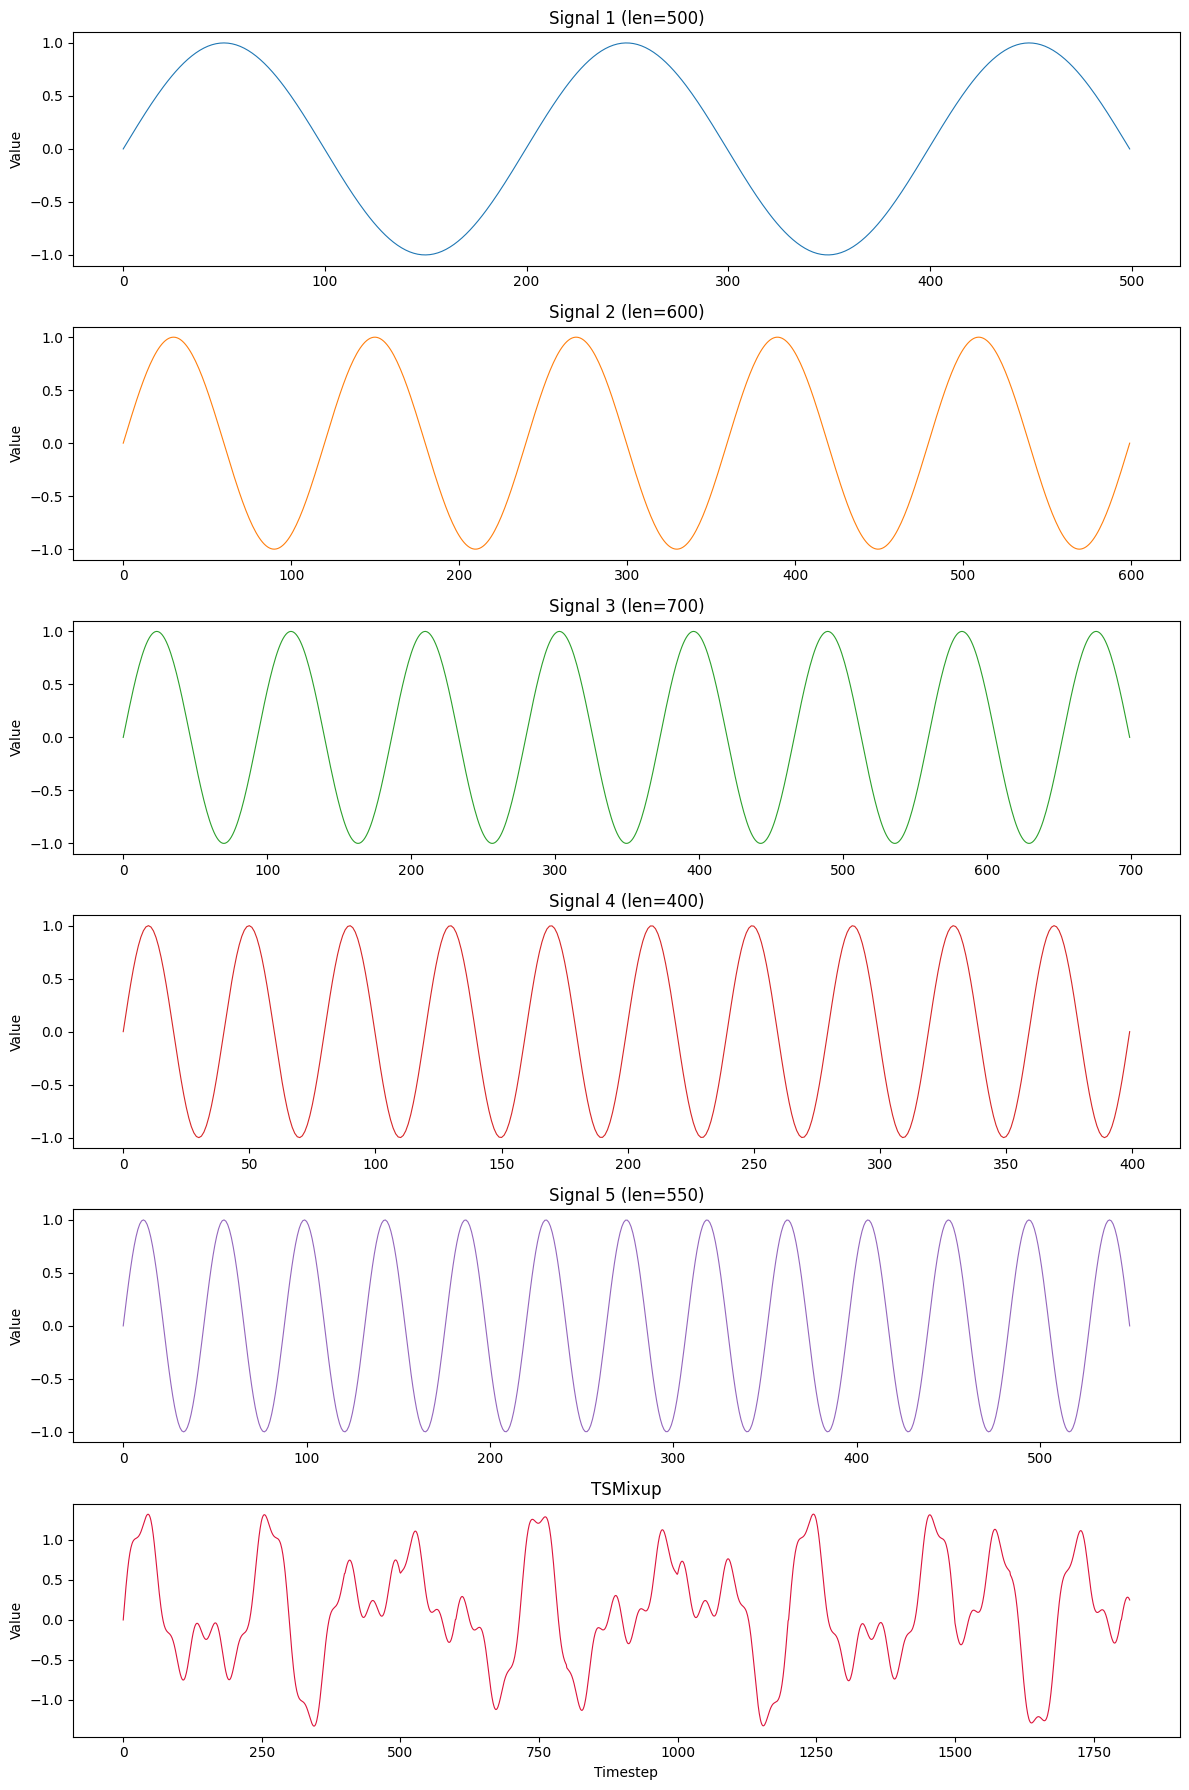

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(datasets) + 1, 1, figsize=(12, 3 * (len(datasets) + 1)))

for i, ds in enumerate(datasets):
    axes[i].plot(ds, linewidth=0.8, color=f"C{i}")
    axes[i].set_title(f"Signal {i+1} (len={len(ds)})")
    axes[i].set_ylabel("Value")

axes[-1].plot(augmented, linewidth=0.8, color="crimson")
axes[-1].set_title("TSMixup")
axes[-1].set_ylabel("Value")
axes[-1].set_xlabel("Timestep")

plt.tight_layout()
plt.savefig("tsmixup.png", dpi=150)
print("Saved in tsmixup.png")

# Kernel Synth

Saved to 'kernelsynth.png'
Kernels used: ['ExpSineSquared(periodicity=336/1024)', '+ ExpSineSquared(periodicity=96/1024)']


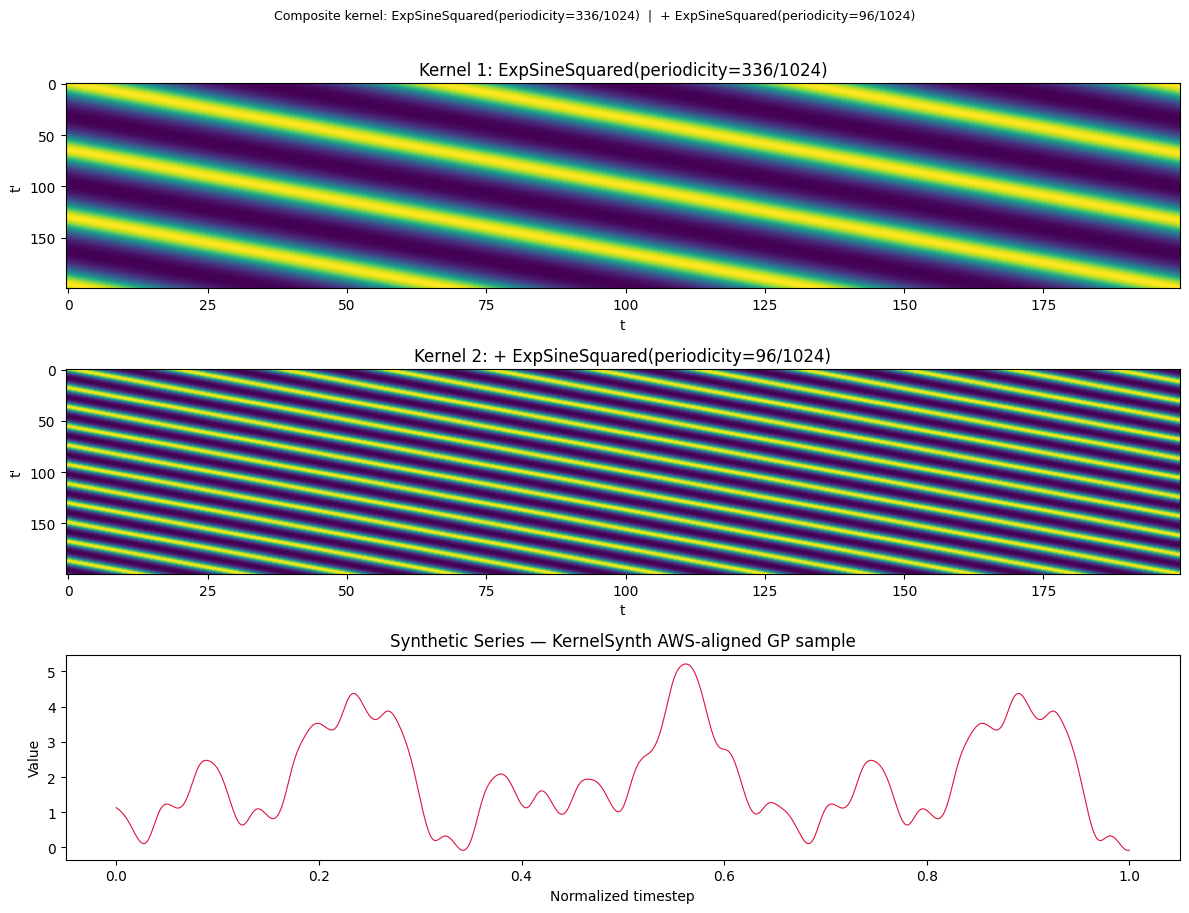

In [ ]:
# KernelSynth implementation aligned with AWS Chronos KernelSynth behavior.
# Keeps explicit matrix construction for didactic/debug purposes.

import numpy as np
import matplotlib.pyplot as plt
from typing import Callable


# ---------------------------------------------------------------------------
# Base kernels
# ---------------------------------------------------------------------------

def kernel_constant(t, tp, C=1.0):
    return np.full((len(t), len(tp)), C, dtype=float)


def kernel_white_noise(t, tp, noise_level=1.0):
    # Same meaning as sklearn WhiteKernel(noise_level=...): value on the diagonal.
    T, Tp = np.meshgrid(t, tp, indexing="ij")
    return noise_level * (T == Tp).astype(float)


def kernel_linear(t, tp, sigma_0=1.0):
    # Equivalent to sklearn DotProduct(sigma_0=sigma_0): sigma_0^2 + x*x'.
    T, Tp = np.meshgrid(t, tp, indexing="ij")
    return sigma_0**2 + T * Tp


def kernel_rbf(t, tp, length_scale=1.0):
    # Equivalent to sklearn RBF(length_scale=...).
    T, Tp = np.meshgrid(t, tp, indexing="ij")
    return np.exp(-0.5 * ((T - Tp) / length_scale) ** 2)


def kernel_rational_quadratic(t, tp, alpha=1.0, length_scale=1.0):
    # Equivalent to sklearn RationalQuadratic(alpha=..., length_scale=1.0).
    T, Tp = np.meshgrid(t, tp, indexing="ij")
    return (1.0 + (T - Tp) ** 2 / (2.0 * alpha * length_scale**2)) ** (-alpha)


def kernel_periodic(t, tp, periodicity=1.0, length_scale=1.0):
    # Equivalent to sklearn ExpSineSquared(periodicity=..., length_scale=1.0).
    T, Tp = np.meshgrid(t, tp, indexing="ij")
    return np.exp(
        -2.0 * np.sin(np.pi * np.abs(T - Tp) / periodicity) ** 2 / length_scale**2
    )


# ---------------------------------------------------------------------------
# AWS-aligned kernel bank
# ---------------------------------------------------------------------------

# Same periodicities as AWS, before normalization by sequence length.
# Duplicates are intentional: AWS has repeated entries, therefore repeated
# kernels must keep higher sampling probability.
AWS_PERIODS = [
    24, 48, 96,
    24 * 7, 48 * 7, 96 * 7,
    7, 14, 30, 60, 365, 365 * 2,
    4, 26, 52,
    4, 6, 12,
    4, 4 * 10,
    10,
]


def build_kernel_bank(l_syn: int = 1024) -> list[tuple[str, Callable]]:
    """Build the KernelSynth bank with AWS-equivalent parameters.

    AWS uses X = linspace(0, 1, LENGTH) and periodicity = raw_period / LENGTH.
    Therefore, if l_syn changes, periodicities must be normalized by l_syn.
    """
    periodic_kernels = [
        (
            f"ExpSineSquared(periodicity={p}/{l_syn})",
            (lambda p=p: lambda t, tp: kernel_periodic(t, tp, periodicity=p / l_syn))(),
        )
        for p in AWS_PERIODS
    ]

    return [
        *periodic_kernels,
        ("DotProduct(sigma_0=0.0)", lambda t, tp: kernel_linear(t, tp, sigma_0=0.0)),
        ("DotProduct(sigma_0=1.0)", lambda t, tp: kernel_linear(t, tp, sigma_0=1.0)),
        ("DotProduct(sigma_0=10.0)", lambda t, tp: kernel_linear(t, tp, sigma_0=10.0)),
        ("RBF(length_scale=0.1)", lambda t, tp: kernel_rbf(t, tp, length_scale=0.1)),
        ("RBF(length_scale=1.0)", lambda t, tp: kernel_rbf(t, tp, length_scale=1.0)),
        ("RBF(length_scale=10.0)", lambda t, tp: kernel_rbf(t, tp, length_scale=10.0)),
        ("RationalQuadratic(alpha=0.1)", lambda t, tp: kernel_rational_quadratic(t, tp, alpha=0.1)),
        ("RationalQuadratic(alpha=1.0)", lambda t, tp: kernel_rational_quadratic(t, tp, alpha=1.0)),
        ("RationalQuadratic(alpha=10.0)", lambda t, tp: kernel_rational_quadratic(t, tp, alpha=10.0)),
        ("WhiteKernel(noise_level=0.1)", lambda t, tp: kernel_white_noise(t, tp, noise_level=0.1)),
        ("WhiteKernel(noise_level=1.0)", lambda t, tp: kernel_white_noise(t, tp, noise_level=1.0)),
        ("ConstantKernel()", lambda t, tp: kernel_constant(t, tp, C=1.0)),
    ]


# ---------------------------------------------------------------------------
# KernelSynth
# ---------------------------------------------------------------------------

def kernel_synth(
    J: int = 5,
    l_syn: int = 1024,
    jitter: float = 0.0,
    return_aws_record: bool = False,
):
    """Generate one KernelSynth time series aligned with AWS behavior.

    Args:
        J: maximum number of kernels to combine.
        l_syn: generated time-series length.
        jitter: optional diagonal stabilization. AWS does not add explicit jitter,
            so the default is 0.0. Use e.g. 1e-6 only if numerical issues appear.
        return_aws_record: if True, return the GluonTS-style dict used by AWS.

    Returns:
        If return_aws_record=False:
            x, kernel_names
        If return_aws_record=True:
            {"start": np.datetime64(...), "target": x}, kernel_names
    """
    kernel_bank = build_kernel_bank(l_syn)

    while True:  # AWS retries when GP sampling fails because of numerical errors.
        t = np.linspace(0, 1, l_syn)

        # Step 1: sample the number of kernels, uniformly in [1, J].
        j = np.random.randint(1, J + 1)

        # Step 2: sample j kernels i.i.d. from the AWS-aligned kernel bank.
        indices = np.random.choice(len(kernel_bank), size=j, replace=True)
        chosen = [kernel_bank[i] for i in indices]

        # Step 3: initialize composite covariance matrix.
        K_star = chosen[0][1](t, t)
        kernel_names = [chosen[0][0]]

        # Step 4: combine kernels using random binary operators (+ or *).
        for name, kfn in chosen[1:]:
            op = np.random.choice(["+", "*"])
            K_new = kfn(t, t)
            if op == "+":
                K_star = K_star + K_new
            else:
                K_star = K_star * K_new
            kernel_names.append(f"{op} {name}")

        if jitter > 0.0:
            K_star = K_star + jitter * np.eye(l_syn)

        # Step 5: sample from GP prior, x ~ N(0, K*).
        # np.random.multivariate_normal accepts positive semidefinite covariance,
        # so it is closer to sklearn's GP sampling than a strict Cholesky-only path.
        try:
            x = np.random.multivariate_normal(mean=np.zeros(l_syn), cov=K_star)
        except np.linalg.LinAlgError as err:
            print("Error caught:", err)
            continue

        if return_aws_record:
            return {
                "start": np.datetime64("2000-01-01 00:00", "s"),
                "target": x,
            }, kernel_names

        return x, kernel_names


# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------

def _clean_kernel_name(name: str) -> str:
    if name.startswith("+ ") or name.startswith("* "):
        return name[2:]
    return name


def plot_kernelsynth(x: np.ndarray, kernel_names: list[str], filepath="kernelsynth.png"):
    t = np.linspace(0, 1, len(x))
    n_kernels = len(kernel_names)
    kernel_bank = build_kernel_bank(len(x))

    fig, axes = plt.subplots(n_kernels + 1, 1, figsize=(12, 3 * (n_kernels + 1)))

    t_small = np.linspace(0, 1, 200)
    for i, name in enumerate(kernel_names):
        clean_name = _clean_kernel_name(name)
        match = next((kfn for kname, kfn in kernel_bank if kname == clean_name), None)
        if match is not None:
            K = match(t_small, t_small)
            axes[i].imshow(K, cmap="viridis", aspect="auto")
            axes[i].set_title(f"Kernel {i + 1}: {name}")
            axes[i].set_xlabel("t")
            axes[i].set_ylabel("t'")
        else:
            axes[i].axis("off")

    axes[-1].plot(t, x, linewidth=0.8, color="crimson")
    axes[-1].set_title("Synthetic Series — KernelSynth AWS-aligned GP sample")
    axes[-1].set_xlabel("Normalized timestep")
    axes[-1].set_ylabel("Value")

    kernel_str = "  |  ".join(kernel_names)
    fig.suptitle(f"Composite kernel: {kernel_str}", fontsize=9, y=1.01)

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    print(f"Saved to '{filepath}'")
    print(f"Kernels used: {kernel_names}")


if __name__ == "__main__":
    x, names = kernel_synth(J=5, l_syn=1024)
    plot_kernelsynth(x, names)
